# Contextual Bandit for LLM Routing

Routes user queries to the best LLM by balancing response quality and inference cost using contextual bandit algorithms.

**Algorithms:**
- LinUCB, LinTS — contextual (use query features)
- EpsilonGreedy, Random — non-contextual baselines

**Ablation (3 conditions for contextual algorithms):**

| Condition | Context features? | Warm-start? |
|---|---|---|
| Context + Warm | ✓ real features | ✓ Stage 1 weights |
| Context + Cold | ✓ real features | ✗ zeros |
| No Context + Cold | ✗ constant vector | ✗ zeros |

**Cost-sensitivity scenarios:** λ = 0.1 (quality-focused), 0.5 (balanced), 1.0 (cost-focused)

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

## 1. Load Data & Stage 1 Outputs

In [2]:
df_full = pd.read_json('data/df_bandit.json', lines=True)
print(f"Dataset: {len(df_full):,} pairwise comparisons")

with open('data/dueling_context_weights.json', 'r') as f:
    context_weights = json.load(f)

with open('data/dueling_training_summary.json', 'r') as f:
    summary = json.load(f)

model_names = summary['model_names']
feature_names = summary['feature_names']
n_models = len(model_names)
n_features = len(feature_names)

print(f"Models: {n_models}")
print(f"Context features ({n_features}): {feature_names}")

Dataset: 25,322 pairwise comparisons
Models: 20
Context features (6): ['length', 'is_analytical', 'is_informational', 'is_creative', 'difficulty', 'is_other']


In [3]:
# Recreate the exact same 50/50 split used in Stage 1 training
np.random.seed(42)
split_mask = np.random.rand(len(df_full)) < 0.5

df = df_full[~split_mask].reset_index(drop=True)
print(f"Evaluation set: {len(df):,} pairs")
print(f"Winner distribution:\n{df['winner'].value_counts().to_string()}")

Evaluation set: 12,726 pairs
Winner distribution:
winner
model_a          4495
model_b          4457
tie (bothbad)    2334
tie              1440


## 2. Cost & Reward Setup

In [4]:
RAW_COST_PER_1K = {
    'gpt-4': 0.03, 'gpt-3.5-turbo': 0.002, 'claude-v1': 0.011,
    'claude-instant-v1': 0.00163, 'palm-2': 0.0005, 'vicuna-13b': 0.0003,
    'vicuna-7b': 0.0002, 'koala-13b': 0.0003, 'oasst-pythia-12b': 0.0002,
    'alpaca-13b': 0.0003, 'chatglm-6b': 0.0002,
    'stablelm-tuned-alpha-7b': 0.0002, 'fastchat-t5-3b': 0.0001,
    'llama-13b': 0.0003, 'dolly-v2-12b': 0.0002,
    'RWKV-4-Raven-14B': 0.0002, 'rwkv-4-raven-14b': 0.0002,
    'mpt-7b-chat': 0.0002,
    'gpt4all-13b-snoozy': 0.0002, 'guanaco-33b': 0.0003,
    'wizardlm-13b': 0.0003,
    'h2ogpt-oig-oasst1-512-6_9b': 0.0002,
}
MAX_COST = max(RAW_COST_PER_1K.values())
normalized_costs = {m: RAW_COST_PER_1K.get(m, 0.0003) / MAX_COST for m in model_names}

def get_quality(row, model_col):
    w = row['winner']
    if w == 'model_a': return 1.0 if model_col == 'model_a' else 0.0
    elif w == 'model_b': return 1.0 if model_col == 'model_b' else 0.0
    elif w == 'tie (bothbad)': return 0.0
    else: return 0.5

## 3. Simulation Data Builder

In [5]:
def build_sim_data(df, lambda_val, use_context=True):
    constant_ctx = np.ones(n_features) / np.sqrt(n_features)
    sim = []
    for _, row in df.iterrows():
        ctx = np.array([row[f] for f in feature_names], dtype=np.float64) if use_context else constant_ctx.copy()
        ma, mb = row['model_a'], row['model_b']
        qa, qb = get_quality(row, 'model_a'), get_quality(row, 'model_b')
        ra = qa - lambda_val * normalized_costs[ma]
        rb = qb - lambda_val * normalized_costs[mb]
        sim.append((ctx, [ma, mb], {ma: ra, mb: rb}))
    return sim

## 4. Algorithm Implementations

In [6]:
class LinUCB:
    def __init__(self, model_names, n_features, alpha=1.0, warm_weights=None):
        self.alpha = alpha
        self.A = {m: np.eye(n_features) for m in model_names}
        self.b = {}
        for m in model_names:
            if warm_weights and m in warm_weights:
                self.b[m] = np.array(warm_weights[m][:n_features]).copy()
            else:
                self.b[m] = np.zeros(n_features)
        self.counts = defaultdict(int)
        self.rewards = []
        self.regrets = []

    def select(self, ctx, available):
        best, best_m = -np.inf, available[0]
        for m in available:
            Ainv = np.linalg.inv(self.A[m])
            theta = Ainv @ self.b[m]
            ucb = theta @ ctx + self.alpha * np.sqrt(ctx @ Ainv @ ctx)
            if ucb > best: best, best_m = ucb, m
        return best_m

    def update(self, m, ctx, r):
        self.A[m] += np.outer(ctx, ctx)
        self.b[m] += r * ctx
        self.counts[m] += 1


class LinTS:
    def __init__(self, model_names, n_features, v=0.5, warm_weights=None):
        self.v = v
        self.B = {m: np.eye(n_features) for m in model_names}
        self.f = {}
        for m in model_names:
            if warm_weights and m in warm_weights:
                self.f[m] = np.array(warm_weights[m][:n_features]).copy()
            else:
                self.f[m] = np.zeros(n_features)
        self.counts = defaultdict(int)
        self.rewards = []
        self.regrets = []

    def select(self, ctx, available):
        best, best_m = -np.inf, available[0]
        for m in available:
            Binv = np.linalg.inv(self.B[m])
            mu = Binv @ self.f[m]
            sample = np.random.multivariate_normal(mu, self.v**2 * Binv)
            score = sample @ ctx
            if score > best: best, best_m = score, m
        return best_m

    def update(self, m, ctx, r):
        self.B[m] += np.outer(ctx, ctx)
        self.f[m] += r * ctx
        self.counts[m] += 1


class EpsilonGreedy:
    def __init__(self, model_names, epsilon=0.5):
        self.epsilon = epsilon
        self.reward_sum = defaultdict(float)
        self.counts = defaultdict(int)
        self.rewards = []
        self.regrets = []

    def select(self, ctx, available):
        if np.random.random() < self.epsilon:
            return np.random.choice(available)
        best, best_m = -np.inf, available[0]
        for m in available:
            score = self.reward_sum[m] / self.counts[m] if self.counts[m] > 0 else 0.0
            if score > best: best, best_m = score, m
        return best_m

    def update(self, m, ctx, r):
        self.reward_sum[m] += r
        self.counts[m] += 1


class RandomPolicy:
    def __init__(self):
        self.counts = defaultdict(int)
        self.rewards = []
        self.regrets = []

    def select(self, ctx, available):
        return np.random.choice(available)

    def update(self, m, ctx, r):
        self.counts[m] += 1

In [7]:
def run_sim(algo, sim_data, name=""):
    for t, (ctx, avail, rewards) in enumerate(sim_data):
        chosen = algo.select(ctx, avail)
        r = rewards[chosen]
        best_r = max(rewards.values())
        algo.rewards.append(r)
        algo.regrets.append(best_r - r)
        algo.update(chosen, ctx, r)
    avg = np.mean(algo.rewards)
    print(f"  {name:<20} Avg Reward: {avg:.4f}  Cum Regret: {sum(algo.regrets):.1f}")
    return algo

## 5. Run Experiments

In [8]:
lambda_values = [0.1, 0.5, 1.0]
algo_names = ['LinUCB', 'LinTS', 'EpsilonGreedy', 'Random']
conditions = ['context_warm', 'context_cold', 'no_context_cold']
results = {c: {} for c in conditions}

for lam in lambda_values:
    print(f"\n{'='*60}")
    print(f"λ = {lam}  ({'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'})")
    print(f"{'='*60}")

    sim = build_sim_data(df, lam, use_context=True)
    sim_nc = build_sim_data(df, lam, use_context=False)

    print("\n  CONTEXT + WARM-START:")
    results['context_warm'][lam] = {}
    np.random.seed(42)
    results['context_warm'][lam]['LinUCB'] = run_sim(LinUCB(model_names, n_features, alpha=1.0, warm_weights=context_weights), sim, 'LinUCB')
    np.random.seed(42)
    results['context_warm'][lam]['LinTS'] = run_sim(LinTS(model_names, n_features, v=0.5, warm_weights=context_weights), sim, 'LinTS')
    np.random.seed(42)
    results['context_warm'][lam]['EpsilonGreedy'] = run_sim(EpsilonGreedy(model_names, epsilon=0.1), sim, 'EpsilonGreedy')
    np.random.seed(42)
    results['context_warm'][lam]['Random'] = run_sim(RandomPolicy(), sim, 'Random')

    print("\n  CONTEXT + COLD-START:")
    results['context_cold'][lam] = {}
    np.random.seed(42)
    results['context_cold'][lam]['LinUCB'] = run_sim(LinUCB(model_names, n_features, alpha=1.0), sim, 'LinUCB')
    np.random.seed(42)
    results['context_cold'][lam]['LinTS'] = run_sim(LinTS(model_names, n_features, v=0.5), sim, 'LinTS')
    results['context_cold'][lam]['EpsilonGreedy'] = results['context_warm'][lam]['EpsilonGreedy']
    results['context_cold'][lam]['Random'] = results['context_warm'][lam]['Random']

    print("\n  NO CONTEXT + COLD-START:")
    results['no_context_cold'][lam] = {}
    np.random.seed(42)
    results['no_context_cold'][lam]['LinUCB'] = run_sim(LinUCB(model_names, n_features, alpha=1.0), sim_nc, 'LinUCB')
    np.random.seed(42)
    results['no_context_cold'][lam]['LinTS'] = run_sim(LinTS(model_names, n_features, v=0.5), sim_nc, 'LinTS')
    results['no_context_cold'][lam]['EpsilonGreedy'] = results['context_warm'][lam]['EpsilonGreedy']
    results['no_context_cold'][lam]['Random'] = results['context_warm'][lam]['Random']

print("\nAll experiments complete.")


λ = 0.1  (Quality)

  CONTEXT + WARM-START:
  LinUCB               Avg Reward: 0.5318  Cum Regret: 2739.3
  LinTS                Avg Reward: 0.5183  Cum Regret: 2910.8
  EpsilonGreedy        Avg Reward: 0.5314  Cum Regret: 2744.9
  Random               Avg Reward: 0.4027  Cum Regret: 4382.7

  CONTEXT + COLD-START:
  LinUCB               Avg Reward: 0.5315  Cum Regret: 2743.1
  LinTS                Avg Reward: 0.5176  Cum Regret: 2919.7

  NO CONTEXT + COLD-START:
  LinUCB               Avg Reward: 0.5561  Cum Regret: 2429.9
  LinTS                Avg Reward: 0.5462  Cum Regret: 2556.2

λ = 0.5  (Balanced)

  CONTEXT + WARM-START:
  LinUCB               Avg Reward: 0.4604  Cum Regret: 2988.1
  LinTS                Avg Reward: 0.4531  Cum Regret: 3080.9
  EpsilonGreedy        Avg Reward: 0.4599  Cum Regret: 2994.2
  Random               Avg Reward: 0.3622  Cum Regret: 4237.4

  CONTEXT + COLD-START:
  LinUCB               Avg Reward: 0.4583  Cum Regret: 3014.0
  LinTS                Av

## 6. Ablation Results

In [9]:
cond_labels = {'context_warm': 'Ctx+Warm', 'context_cold': 'Ctx+Cold', 'no_context_cold': 'NoCxt+Cold'}

rows = []
for lam in lambda_values:
    for algo in algo_names:
        row = {'λ': lam, 'Algorithm': algo}
        for cond in conditions:
            row[cond_labels[cond]] = round(np.mean(results[cond][lam][algo].rewards), 4)
        ctx_cold = np.mean(results['context_cold'][lam][algo].rewards)
        nc_cold  = np.mean(results['no_context_cold'][lam][algo].rewards)
        ctx_warm = np.mean(results['context_warm'][lam][algo].rewards)
        if algo in ['LinUCB', 'LinTS']:
            row['Context Effect']    = round(ctx_cold - nc_cold, 4)
            row['Warm-start Effect'] = round(ctx_warm - ctx_cold, 4)
        else:
            row['Context Effect'] = row['Warm-start Effect'] = 'N/A'
        rows.append(row)

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

print("\nStatistical Tests (contextual algorithms only):")
print(f"{'λ':<6} {'Algorithm':<16} {'Comparison':<30} {'Δ':>8} {'p':>10} {'Sig':>5}")
print("-"*75)
for lam in lambda_values:
    for algo in ['LinUCB', 'LinTS']:
        r_ctx  = results['context_cold'][lam][algo].rewards
        r_nc   = results['no_context_cold'][lam][algo].rewards
        r_warm = results['context_warm'][lam][algo].rewards
        _, p = stats.ttest_rel(r_ctx, r_nc)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        print(f"{lam:<6} {algo:<16} {'Context vs No-Context':<30} {np.mean(r_ctx)-np.mean(r_nc):+.4f} {p:>10.4f} {sig:>5}")
        _, p = stats.ttest_rel(r_warm, r_ctx)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        print(f"{lam:<6} {algo:<16} {'Warm vs Cold':<30} {np.mean(r_warm)-np.mean(r_ctx):+.4f} {p:>10.4f} {sig:>5}")

print("\nContextual vs Non-contextual:")
for lam in lambda_values:
    eg_r = results['context_warm'][lam]['EpsilonGreedy'].rewards
    for algo in ['LinUCB', 'LinTS']:
        r = results['context_warm'][lam][algo].rewards
        _, p = stats.ttest_rel(r, eg_r)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        print(f"  λ={lam}  {algo} vs EpsilonGreedy  Δ={np.mean(r)-np.mean(eg_r):+.4f}  p={p:.4f} {sig}")

  λ     Algorithm  Ctx+Warm  Ctx+Cold  NoCxt+Cold Context Effect Warm-start Effect
0.1        LinUCB    0.5318    0.5315      0.5561        -0.0246            0.0003
0.1         LinTS    0.5183    0.5176      0.5462        -0.0286            0.0007
0.1 EpsilonGreedy    0.5314    0.5314      0.5314            N/A               N/A
0.1        Random    0.4027    0.4027      0.4027            N/A               N/A
0.5        LinUCB    0.4604    0.4583      0.4763         -0.018             0.002
0.5         LinTS    0.4531    0.4485      0.4718        -0.0233            0.0045
0.5 EpsilonGreedy    0.4599    0.4599      0.4599            N/A               N/A
0.5        Random    0.3622    0.3622      0.3622            N/A               N/A
1.0        LinUCB    0.4218    0.4191      0.4396        -0.0205            0.0026
1.0         LinTS    0.4092    0.4088      0.4340        -0.0251            0.0004
1.0 EpsilonGreedy    0.4143    0.4143      0.4143            N/A               N/A
1.0 

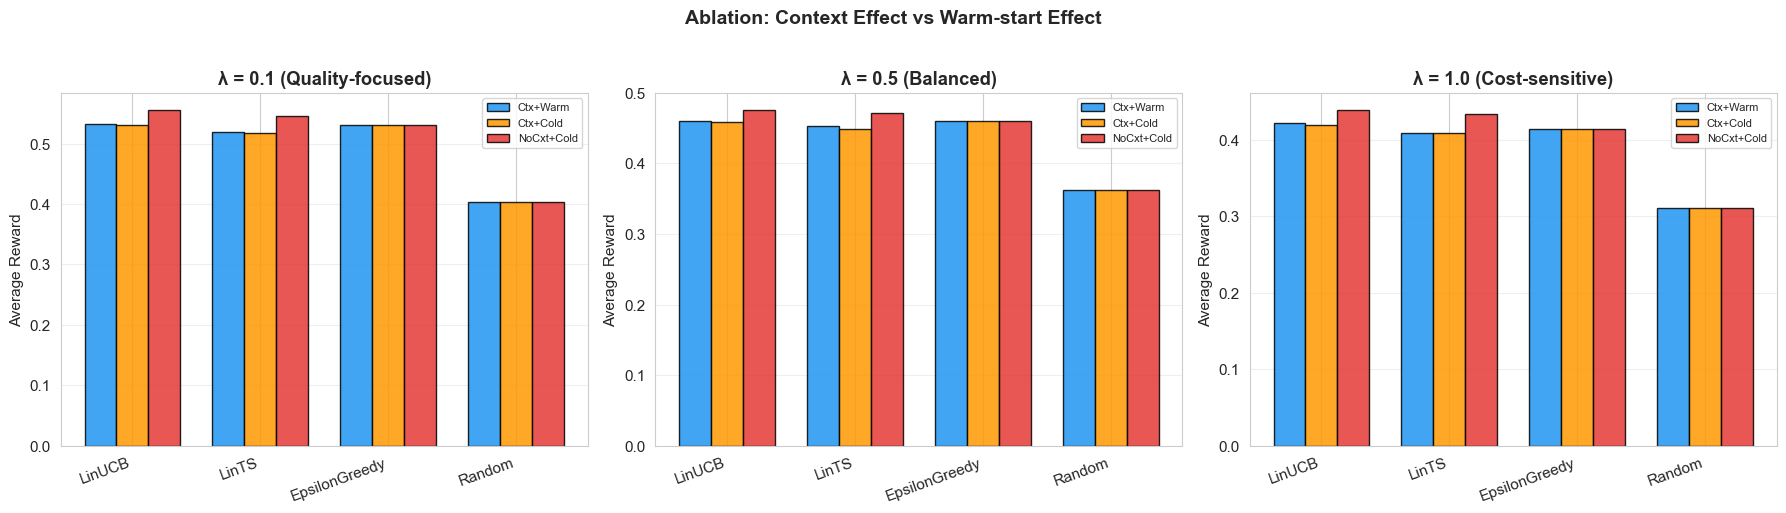

In [10]:
algos_plot = ['LinUCB', 'LinTS', 'EpsilonGreedy', 'Random']
cond_colors = {'context_warm': '#2196F3', 'context_cold': '#FF9800', 'no_context_cold': '#E53935'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    x = np.arange(len(algos_plot))
    w = 0.25
    for ci, cond in enumerate(conditions):
        vals = [np.mean(results[cond][lam][a].rewards) for a in algos_plot]
        ax.bar(x + (ci - 1) * w, vals, w, label=cond_labels[cond], color=cond_colors[cond], edgecolor='black', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(algos_plot, rotation=20, ha='right')
    ax.set_ylabel('Average Reward')
    label = 'Quality-focused' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Ablation: Context Effect vs Warm-start Effect', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('context_vs_nocontext.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cumulative Reward & Regret

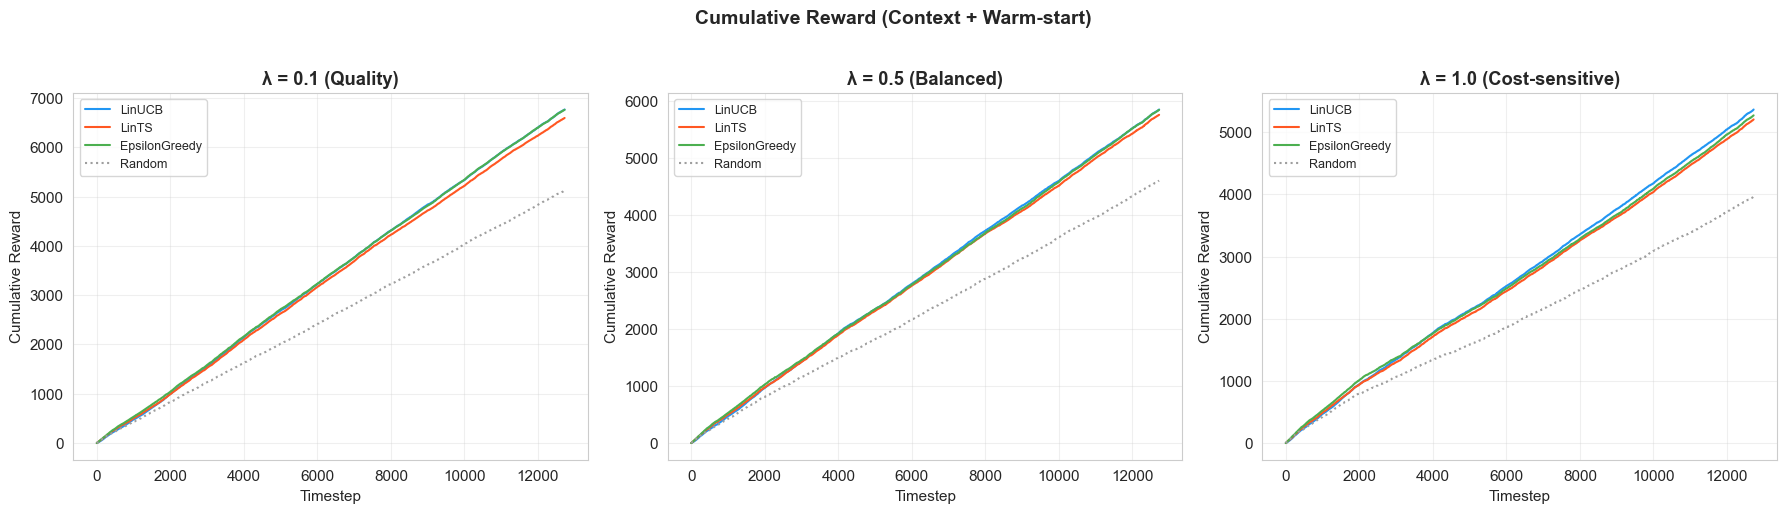

In [11]:
colors = {'LinUCB': '#2196F3', 'LinTS': '#FF5722', 'EpsilonGreedy': '#4CAF50', 'Random': '#9E9E9E'}
styles = {'LinUCB': '-', 'LinTS': '-', 'EpsilonGreedy': '-', 'Random': ':'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    for algo in algos_plot:
        cum = np.cumsum(results['context_warm'][lam][algo].rewards)
        ax.plot(cum, label=algo, color=colors[algo], linewidth=1.5, linestyle=styles[algo])
    label = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Reward')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Cumulative Reward (Context + Warm-start)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cumulative_reward.png', dpi=150, bbox_inches='tight')
plt.show()

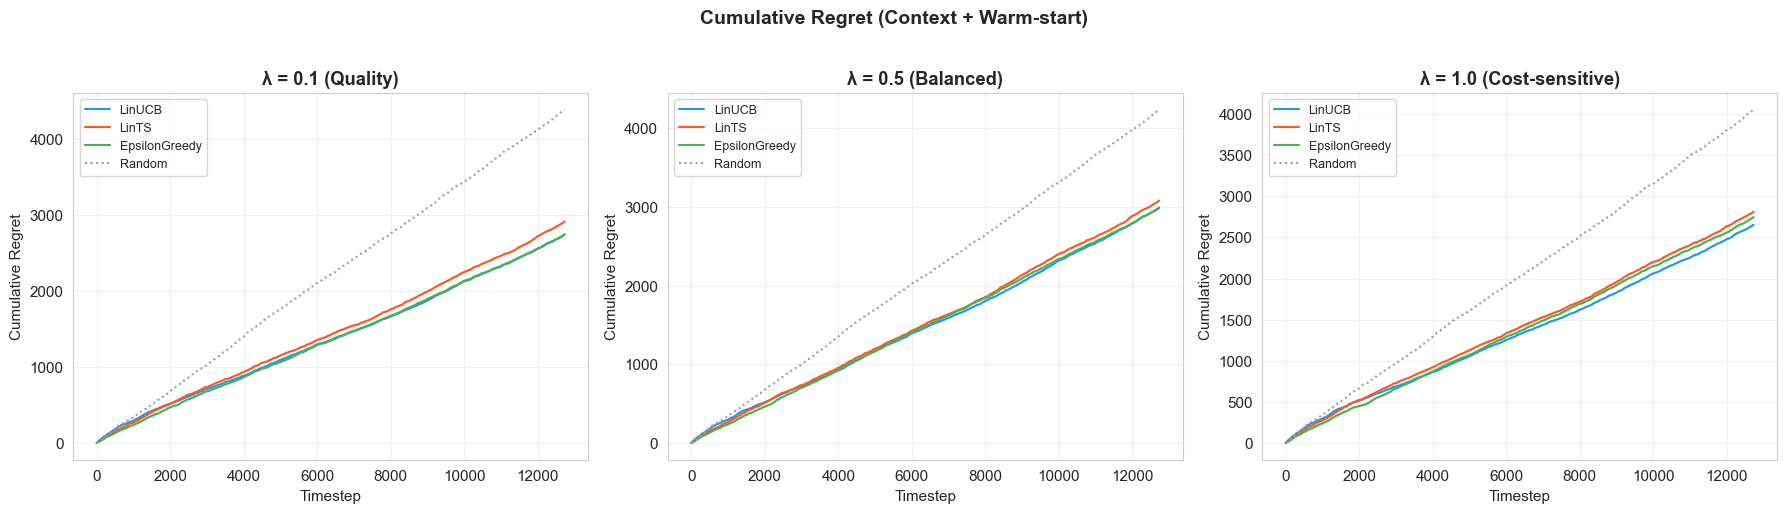

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    for algo in algos_plot:
        cum = np.cumsum(results['context_warm'][lam][algo].regrets)
        ax.plot(cum, label=algo, color=colors[algo], linewidth=1.5, linestyle=styles[algo])
    label = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Regret')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Cumulative Regret (Context + Warm-start)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cumulative_regret.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Selection Frequency

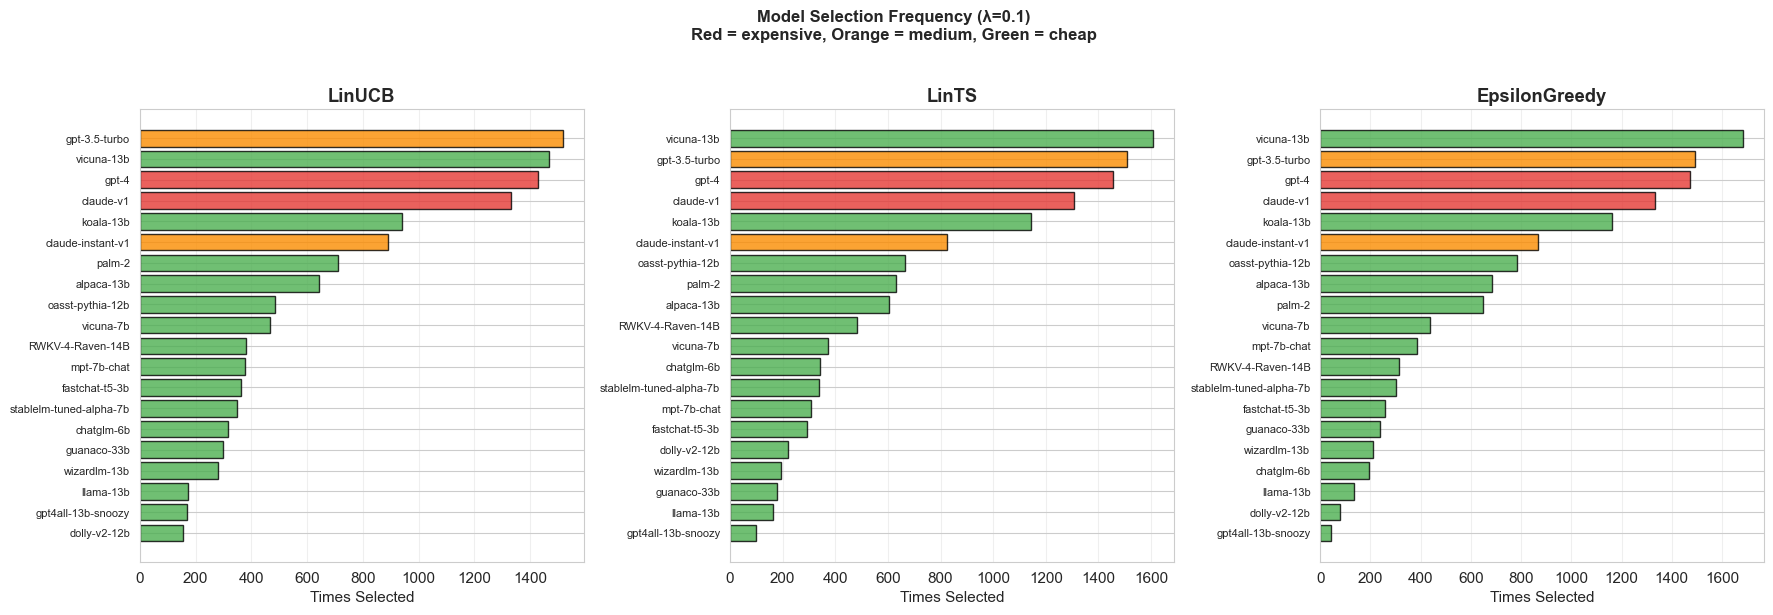

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, algo in enumerate(['LinUCB', 'LinTS', 'EpsilonGreedy']):
    ax = axes[idx]
    counts = results['context_warm'][0.1][algo].counts
    models_sorted = sorted(counts.keys(), key=lambda m: counts[m], reverse=True)
    vals = [counts[m] for m in models_sorted]
    bar_colors = []
    for m in models_sorted:
        cost = normalized_costs[m]
        if cost > 0.3: bar_colors.append('#E53935')
        elif cost > 0.05: bar_colors.append('#FB8C00')
        else: bar_colors.append('#4CAF50')
    ax.barh(range(len(models_sorted)), vals, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(models_sorted)))
    ax.set_yticklabels(models_sorted, fontsize=8)
    ax.set_xlabel('Times Selected')
    ax.set_title(f'{algo}', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Selection Frequency (λ=0.1)\nRed = expensive, Orange = medium, Green = cheap',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Context & Warm-start Gain Heatmap

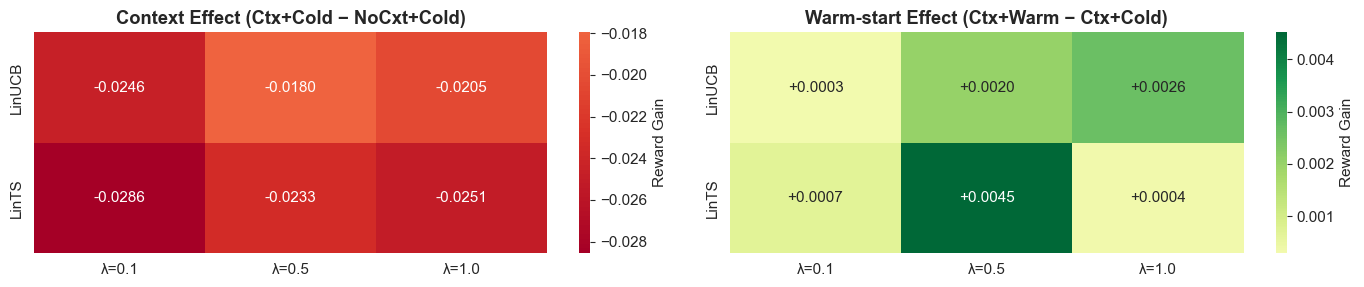

In [14]:
algos_heat = ['LinUCB', 'LinTS']
context_gain = np.zeros((len(algos_heat), len(lambda_values)))
warm_gain    = np.zeros((len(algos_heat), len(lambda_values)))

for i, algo in enumerate(algos_heat):
    for j, lam in enumerate(lambda_values):
        ctx_cold = np.mean(results['context_cold'][lam][algo].rewards)
        nc_cold  = np.mean(results['no_context_cold'][lam][algo].rewards)
        ctx_warm = np.mean(results['context_warm'][lam][algo].rewards)
        context_gain[i, j] = ctx_cold - nc_cold
        warm_gain[i, j]    = ctx_warm - ctx_cold

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
sns.heatmap(context_gain, xticklabels=[f'λ={l}' for l in lambda_values],
            yticklabels=algos_heat, annot=True, fmt='+.4f', center=0,
            cmap='RdYlGn', ax=axes[0], cbar_kws={'label': 'Reward Gain'})
axes[0].set_title('Context Effect (Ctx+Cold − NoCxt+Cold)', fontweight='bold')

sns.heatmap(warm_gain, xticklabels=[f'λ={l}' for l in lambda_values],
            yticklabels=algos_heat, annot=True, fmt='+.4f', center=0,
            cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Reward Gain'})
axes[1].set_title('Warm-start Effect (Ctx+Warm − Ctx+Cold)', fontweight='bold')

plt.tight_layout()
plt.savefig('context_gain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

In [15]:
output = {
    'config': {
        'algorithms': algo_names,
        'lambda_values': lambda_values,
        'conditions': conditions,
        'n_models': n_models,
        'n_features': n_features,
        'n_eval_pairs': len(df),
        'features': feature_names,
    },
}
for cond in conditions:
    output[cond] = {}
    for lam in lambda_values:
        output[cond][str(lam)] = {}
        for algo in algo_names:
            output[cond][str(lam)][algo] = {
                'avg_reward': float(np.mean(results[cond][lam][algo].rewards)),
                'cumulative_regret': float(sum(results[cond][lam][algo].regrets)),
                'selection_counts': dict(results[cond][lam][algo].counts),
            }

with open('bandit_routing_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print("Results saved to bandit_routing_results.json")

Results saved to bandit_routing_results.json


## 11. Summary

In [16]:
print("="*60)
print("SUMMARY")
print("="*60)

print("\n1. DOES CONTEXT HELP? (Ctx+Cold vs NoCxt+Cold)")
for algo in ['LinUCB', 'LinTS']:
    gains = [np.mean(results['context_cold'][l][algo].rewards) - np.mean(results['no_context_cold'][l][algo].rewards)
             for l in lambda_values]
    avg_gain = np.mean(gains)
    verdict = 'YES' if avg_gain > 0.001 else ('NO (hurts)' if avg_gain < -0.001 else 'NEGLIGIBLE')
    print(f"   {algo:<18} Avg gain: {avg_gain:+.4f}  → {verdict}")
print("   EpsilonGreedy    N/A (context-free)")

print("\n2. DOES WARM-START HELP? (Ctx+Warm vs Ctx+Cold)")
for algo in ['LinUCB', 'LinTS']:
    gains = [np.mean(results['context_warm'][l][algo].rewards) - np.mean(results['context_cold'][l][algo].rewards)
             for l in lambda_values]
    avg_gain = np.mean(gains)
    verdict = 'YES' if avg_gain > 0.001 else ('NO (hurts)' if avg_gain < -0.001 else 'NEGLIGIBLE')
    print(f"   {algo:<18} Avg gain: {avg_gain:+.4f}  → {verdict}")

print("\n3. CONTEXTUAL vs NON-CONTEXTUAL (Ctx+Warm vs EpsilonGreedy)")
for algo in ['LinUCB', 'LinTS']:
    gains = [np.mean(results['context_warm'][l][algo].rewards) - np.mean(results['context_warm'][l]['EpsilonGreedy'].rewards)
             for l in lambda_values]
    avg_gain = np.mean(gains)
    verdict = 'YES' if avg_gain > 0.001 else ('NO' if avg_gain < -0.001 else 'NEGLIGIBLE')
    print(f"   {algo} vs EpsilonGreedy  Avg gain: {avg_gain:+.4f}  → {verdict}")

print("\n4. BEST ALGORITHM PER λ:")
for lam in lambda_values:
    best_algo = max(['LinUCB', 'LinTS', 'EpsilonGreedy'],
                    key=lambda a: np.mean(results['context_warm'][lam][a].rewards))
    best_r = np.mean(results['context_warm'][lam][best_algo].rewards)
    rand_r = np.mean(results['context_warm'][lam]['Random'].rewards)
    label  = 'Quality' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost'
    print(f"   λ={lam} ({label:>8}):  {best_algo} ({best_r:.4f}) vs Random ({rand_r:.4f})")

print("\n5. IMPROVEMENT OVER RANDOM:")
for lam in lambda_values:
    rand_r = np.mean(results['context_warm'][lam]['Random'].rewards)
    for algo in ['LinUCB', 'LinTS', 'EpsilonGreedy']:
        r   = np.mean(results['context_warm'][lam][algo].rewards)
        pct = ((r - rand_r) / abs(rand_r)) * 100
        print(f"   λ={lam}  {algo:<16}  +{pct:.1f}% over Random")

print("\n" + "="*60)

SUMMARY

1. DOES CONTEXT HELP? (Ctx+Cold vs NoCxt+Cold)
   LinUCB             Avg gain: -0.0210  → NO (hurts)
   LinTS              Avg gain: -0.0257  → NO (hurts)
   EpsilonGreedy    N/A (context-free)

2. DOES WARM-START HELP? (Ctx+Warm vs Ctx+Cold)
   LinUCB             Avg gain: +0.0016  → YES
   LinTS              Avg gain: +0.0019  → YES

3. CONTEXTUAL vs NON-CONTEXTUAL (Ctx+Warm vs EpsilonGreedy)
   LinUCB vs EpsilonGreedy  Avg gain: +0.0028  → YES
   LinTS vs EpsilonGreedy  Avg gain: -0.0083  → NO

4. BEST ALGORITHM PER λ:
   λ=0.1 ( Quality):  LinUCB (0.5318) vs Random (0.4027)
   λ=0.5 (Balanced):  LinUCB (0.4604) vs Random (0.3622)
   λ=1.0 (    Cost):  LinUCB (0.4218) vs Random (0.3116)

5. IMPROVEMENT OVER RANDOM:
   λ=0.1  LinUCB            +32.1% over Random
   λ=0.1  LinTS             +28.7% over Random
   λ=0.1  EpsilonGreedy     +32.0% over Random
   λ=0.5  LinUCB            +27.1% over Random
   λ=0.5  LinTS             +25.1% over Random
   λ=0.5  EpsilonGreedy     